## Exercise 2 — **Car travel in 2 dimensions**

The goal of this exercise is to familiarise with:
- code structure `# Physics, # Numerics, # Time loop, # Visualisation`
- array initialisation
- 2 spatial dimensions
- solving ODEs

Based on the experience you acquired solving the [Exercise 1](#exercise_1_-_car_travel) we can now consider a car moving within a 2-dimensional space. The car still travels at speed $V=113$ km/h, but now in North-East or North-West direction. The West-East and South-North directions being the $x$ and $y$ axis, respectively. The car's displacement in the West-East directions is limited to $L=200$ km. The speed in the North direction remains constant.

Starting from the 1D code done in [Exercise 1](#exercise_1_-_car_travel), work towards adding the second spatial dimension. Now, the car's position $(x,y)$ as function of time $t$ has two components.

> 💡 hint:
> - Split velocity magnitude $V$ into $x$ and $y$ component
> - Use `sind()` or `cosd()` functions if passing the angle in _deg_ instead of _rad_
> - Use two vectors or an array to store the car's coordinates
> - Define the y-axis extend in the plot `ylims=(0, ttot*Vy)`

### Question 1

Visualise graphically the trajectory of the travelling car for a simulation with time step parameter defined as `dt = 0.1`.

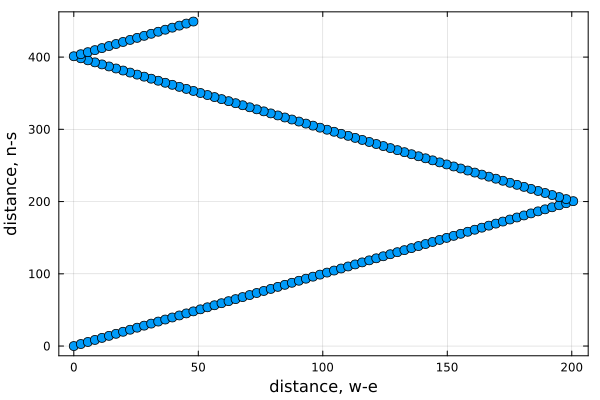

In [19]:
using Plots

@views function car_travel_2D()
    # Physical parameters
    V     = [(√(113)/2)^2,(√(113)/2)^2]     # speed, km/h
    L     = 200     # length of segment, km
    ttot  = 16      # total time, h
    # Numerical parameters
    dt    = 0.1            # time step, h
    nt    = Int(cld(ttot, dt))  # number of time steps
    # Array initialisation
    T     = zeros(nt)
    X     = zeros(2, nt)
    # Time loop
    for it = 2:nt
        T[it] = T[it-1] + dt
        X[1,it] = X[1,it-1] + V[1] * dt  # move the car
        X[2,it] = X[2,it-1] + V[2] * dt  # move the car
        if X[2,it] > L
            V = [V[1], -V[2]]    # if beyond L, go back (left)
        elseif X[2,it] < 0
            V = [V[1], -V[2]]    # if beyond 0, go back (right)
        end
    end
    # Visualisation
    display(scatter(X[2,:], X[1, :], markersize=5,
                    xlabel="distance, w-e", ylabel="distance, n-s",
                    framestyle=:box, legend=:none))
    return
end

car_travel_2D()